# 🛒 Customer Intelligence System
## Phase 3: Customer Segmentation

**Input:** `df_processed_mm.csv` (MinMax-scaled from Phase 2)  
**Goal:** Discover natural customer segments via KMeans, visualize with PCA, name each persona, and profile cluster behavior.

---
### Notebook Sections
1. Setup & Data Loading
2. Feature Selection for Clustering
3. Optimal K — Elbow + Silhouette Method
4. KMeans Clustering
5. PCA — 2D & 3D Visualization
6. Cluster Profiling & Persona Naming
7. Heatmap of Cluster Means
8. Save Segmented Data

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Plot styling — consistent across all phases
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')
COLORS = sns.color_palette('tab10', 10)

RANDOM_STATE = 42
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [2]:
# Load MinMax-scaled data from Phase 2
FILE_PATH_MM  = 'df_processed_mm.csv'   # MinMaxScaled — for KMeans
FILE_PATH_RAW = 'df_processed_raw.csv'  # Raw values   — for profiling

df_mm  = pd.read_csv(FILE_PATH_MM)
df_raw = pd.read_csv(FILE_PATH_RAW)

print(f'MinMax dataset shape : {df_mm.shape}')
print(f'Raw dataset shape    : {df_raw.shape}')
print('\n🔍 First 3 rows (MinMax):')
df_mm.head(3)

MinMax dataset shape : (1000000, 851)
Raw dataset shape    : (1000000, 851)

🔍 First 3 rows (MinMax):


,user_id,age,income_level,has_children,household_size,weekly_purchases,monthly_spend,cart_abandonment_rate,review_writing_frequency,average_order_value,...,last_purchase_date_2026-12-26,last_purchase_date_2026-12-27,last_purchase_date_2026-12-28,last_purchase_date_2026-12-29,last_purchase_date_2026-12-30,last_purchase_date_2026-12-31,last_purchase_date_2027-01-01,engagement_score,value_score,risk_score
0,1,0.612903,0.425579,0,0.444444,0.20,0.4810,0.000000,0.375,0.887755,...,0,0,0,0,0,0,0,0.646667,0.38480,0.233333
1,2,0.822581,0.133805,1,0.111111,0.65,0.7302,0.311111,0.750,0.344898,...,0,0,0,0,0,0,0,0.448095,0.21906,0.460370
2,3,0.451613,0.060353,1,0.555556,0.50,0.4090,0.155556,0.125,0.032653,...,0,0,0,0,0,0,0,0.640000,0.20450,0.328519


## 2. Feature Selection for Clustering

We cluster on a curated set of **behavioral and value features** — not all 45+ columns.  
Rationale: Including OHE dummy columns (100+ sparse binary features) dilutes distance metrics and degrades cluster quality.

In [3]:
# Core clustering features — behavioral, spending, engagement, and risk signals
CLUSTER_FEATURES = [
    # Spending & value
    'monthly_spend',
    'average_order_value',
    'weekly_purchases',
    # Loyalty & retention
    'loyalty_program_member',
    'brand_loyalty_score',
    'referral_count',
    # Engagement
    'daily_session_time_minutes',
    'product_views_per_day',
    'purchase_conversion_rate',
    # Risk signals
    'return_rate',
    'cart_abandonment_rate',
    'checkout_abandonments_per_month',
    # Engineered features
    'engagement_score',
    'value_score',
    'risk_score',
]

# Keep only features that exist in the dataset
CLUSTER_FEATURES = [f for f in CLUSTER_FEATURES if f in df_mm.columns]

X = df_mm[CLUSTER_FEATURES].copy()

print(f'Clustering on {len(CLUSTER_FEATURES)} features:')
for f in CLUSTER_FEATURES:
    print(f'  • {f}')
print(f'\nMatrix shape: {X.shape}')
print(f'Any NaN: {X.isnull().sum().sum()}')

Clustering on 15 features:
  • monthly_spend
  • average_order_value
  • weekly_purchases
  • loyalty_program_member
  • brand_loyalty_score
  • referral_count
  • daily_session_time_minutes
  • product_views_per_day
  • purchase_conversion_rate
  • return_rate
  • cart_abandonment_rate
  • checkout_abandonments_per_month
  • engagement_score
  • value_score
  • risk_score

Matrix shape: (1000000, 15)
Any NaN: 0


## 3. Optimal K — Elbow + Silhouette Method

We use **two complementary methods**:
- **Elbow (Inertia)** — plot WCSS vs K; look for the "elbow" where gains diminish
- **Silhouette Score** — measures how well-separated clusters are (higher = better, max = 1.0)

In [4]:
# Sample for speed on large datasets (KMeans is O(n*k*iter))
MAX_SAMPLE = 50_000
if len(X) > MAX_SAMPLE:
    X_sample = X.sample(n=MAX_SAMPLE, random_state=RANDOM_STATE)
    print(f'Sampled {MAX_SAMPLE:,} rows for elbow/silhouette computation')
else:
    X_sample = X.copy()
    print(f'Using full dataset ({len(X):,} rows)')

Sampled 50,000 rows for elbow/silhouette computation


In [5]:
# ── Compute inertia & silhouette for K = 2..10 ───────────────────────────────
K_RANGE = range(2, 11)

inertias    = []
sil_scores  = []

print('Computing KMeans for K = 2 to 10 ...')
for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                random_state=RANDOM_STATE, max_iter=300)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sample, labels, sample_size=min(10_000, len(X_sample)),
                           random_state=RANDOM_STATE)
    sil_scores.append(sil)
    print(f'  K={k:2d}  Inertia={km.inertia_:,.1f}   Silhouette={sil:.4f}')

print('\n✅ Done')

Computing KMeans for K = 2 to 10 ...
  K= 2  Inertia=53,871.9   Silhouette=0.1839
  K= 3  Inertia=51,396.1   Silhouette=0.1280
  K= 4  Inertia=49,267.3   Silhouette=0.0826
  K= 5  Inertia=47,796.3   Silhouette=0.0778
  K= 6  Inertia=46,557.3   Silhouette=0.0717
  K= 7  Inertia=45,623.0   Silhouette=0.0689
  K= 8  Inertia=44,724.1   Silhouette=0.0681
  K= 9  Inertia=44,046.4   Silhouette=0.0658
  K=10  Inertia=43,447.0   Silhouette=0.0636

✅ Done


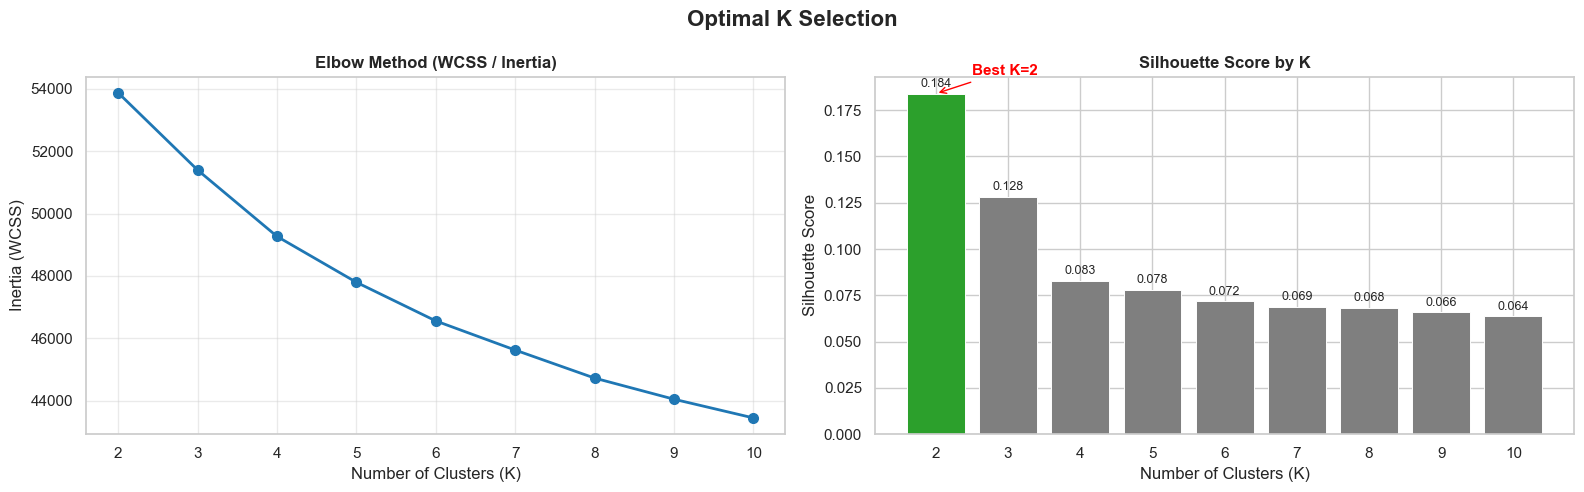


📌 Silhouette best K = 2 (score = 0.1839)
   → Inspect the elbow plot and use domain judgment to confirm K.


In [6]:
# ── Elbow + Silhouette dual plot ──────────────────────────────────────────────
k_list = list(K_RANGE)
best_k_sil = k_list[np.argmax(sil_scores)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Optimal K Selection', fontsize=16, fontweight='bold')

# Elbow
axes[0].plot(k_list, inertias, marker='o', linewidth=2, color=COLORS[0], markersize=7)
axes[0].set_title('Elbow Method (WCSS / Inertia)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_xticks(k_list)
axes[0].grid(True, alpha=0.4)

# Silhouette
bar_colors = [COLORS[2] if k == best_k_sil else COLORS[7] for k in k_list]
bars = axes[1].bar(k_list, sil_scores, color=bar_colors, edgecolor='white', linewidth=0.7)
axes[1].set_title('Silhouette Score by K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(k_list)
for bar, score in zip(bars, sil_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{score:.3f}', ha='center', va='bottom', fontsize=9)
axes[1].annotate(f'Best K={best_k_sil}', xy=(best_k_sil, max(sil_scores)),
                 xytext=(best_k_sil + 0.5, max(sil_scores) + 0.01),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n📌 Silhouette best K = {best_k_sil} (score = {max(sil_scores):.4f})')
print('   → Inspect the elbow plot and use domain judgment to confirm K.')

In [7]:
# ── Set final K ───────────────────────────────────────────────────────────────
# Adjust manually if elbow suggests a different K than silhouette.
# Common choice for e-commerce: 4–6 segments.
K = best_k_sil  # ← Override here if needed, e.g. K = 5

print(f'✅ Final K selected: {K}')

✅ Final K selected: 2


## 4. KMeans Clustering

In [8]:
# ── Fit final KMeans on FULL dataset ─────────────────────────────────────────
kmeans = KMeans(
    n_clusters=K,
    init='k-means++',
    n_init=20,             # more restarts for stability
    max_iter=500,
    random_state=RANDOM_STATE
)

cluster_labels = kmeans.fit_predict(X)

# Attach cluster labels to both raw and scaled dataframes
df_mm['cluster']  = cluster_labels
df_raw['cluster'] = cluster_labels

# Cluster size distribution
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print(f'Final KMeans — K={K}, Inertia={kmeans.inertia_:,.2f}')
print(f'\nCluster size distribution:')
for c, n in cluster_counts.items():
    print(f'  Cluster {c}: {n:>8,} rows  ({n/len(X)*100:.1f}%)')

Final KMeans — K=2, Inertia=1,077,713.59

Cluster size distribution:
  Cluster 0:  500,182 rows  (50.0%)
  Cluster 1:  499,818 rows  (50.0%)


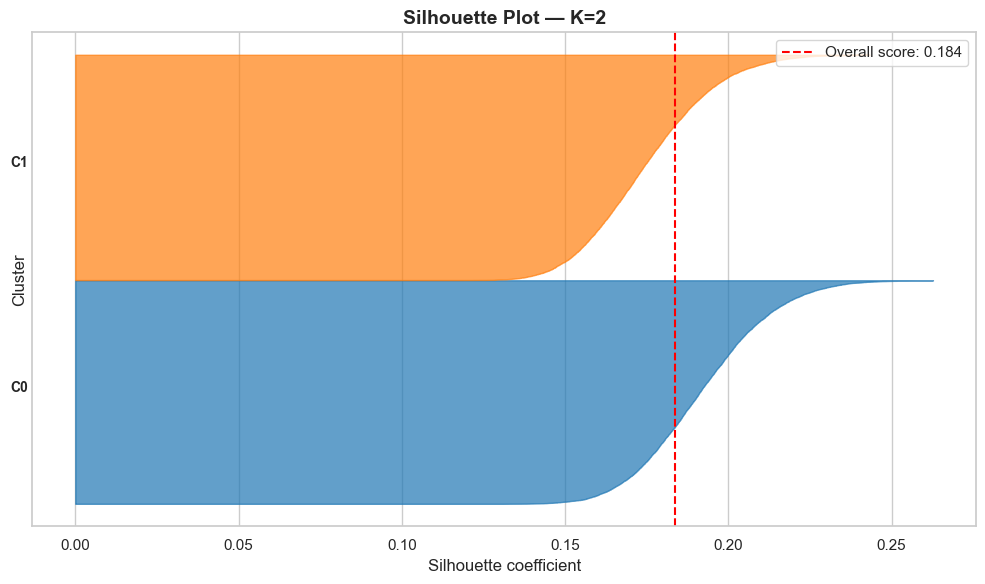

Overall Silhouette Score (K=2): 0.1835


In [9]:
# ── Silhouette plot per cluster ───────────────────────────────────────────────
# Shows how well each sample fits its cluster vs. its neighbours

sil_vals_sample = X.sample(min(20_000, len(X)), random_state=RANDOM_STATE)
sil_labels_sample = kmeans.predict(sil_vals_sample)

sample_silhouette_values = silhouette_samples(sil_vals_sample, sil_labels_sample)
overall_sil = silhouette_score(sil_vals_sample, sil_labels_sample)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for i in range(K):
    ith_cluster_sil = np.sort(sample_silhouette_values[sil_labels_sample == i])
    size = ith_cluster_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil,
                     facecolor=COLORS[i], edgecolor=COLORS[i], alpha=0.7)
    ax.text(-0.02, y_lower + 0.5 * size, f'C{i}', fontsize=10, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=overall_sil, color='red', linestyle='--', linewidth=1.5,
           label=f'Overall score: {overall_sil:.3f}')
ax.set_title(f'Silhouette Plot — K={K}', fontsize=14, fontweight='bold')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f'Overall Silhouette Score (K={K}): {overall_sil:.4f}')

## 5. PCA — 2D & 3D Visualization

PCA reduces our feature matrix to 2–3 components for visualization. It does **not** change the clusters — it's purely for visual inspection.

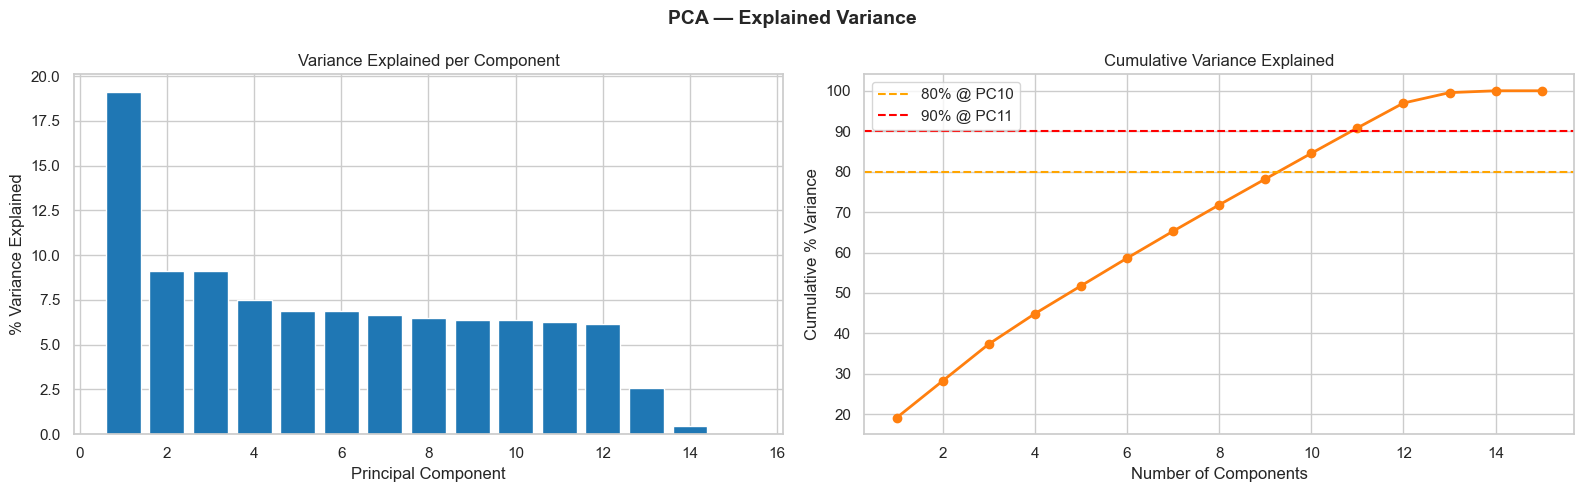

PC1 + PC2 explain: 28.3% of variance
80% variance reached at: 10 components
90% variance reached at: 11 components


In [10]:
# ── Fit PCA ───────────────────────────────────────────────────────────────────
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# How many components to reach 80% / 90% variance
n_80 = np.argmax(cumulative >= 0.80) + 1
n_90 = np.argmax(cumulative >= 0.90) + 1

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('PCA — Explained Variance', fontsize=14, fontweight='bold')

axes[0].bar(range(1, len(explained)+1), explained * 100, color=COLORS[0], edgecolor='white')
axes[0].set_title('Variance Explained per Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('% Variance Explained')

axes[1].plot(range(1, len(cumulative)+1), cumulative * 100, marker='o',
             linewidth=2, color=COLORS[1])
axes[1].axhline(80, color='orange', linestyle='--', label=f'80% @ PC{n_80}')
axes[1].axhline(90, color='red',    linestyle='--', label=f'90% @ PC{n_90}')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative % Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'PC1 + PC2 explain: {(explained[0]+explained[1])*100:.1f}% of variance')
print(f'80% variance reached at: {n_80} components')
print(f'90% variance reached at: {n_90} components')

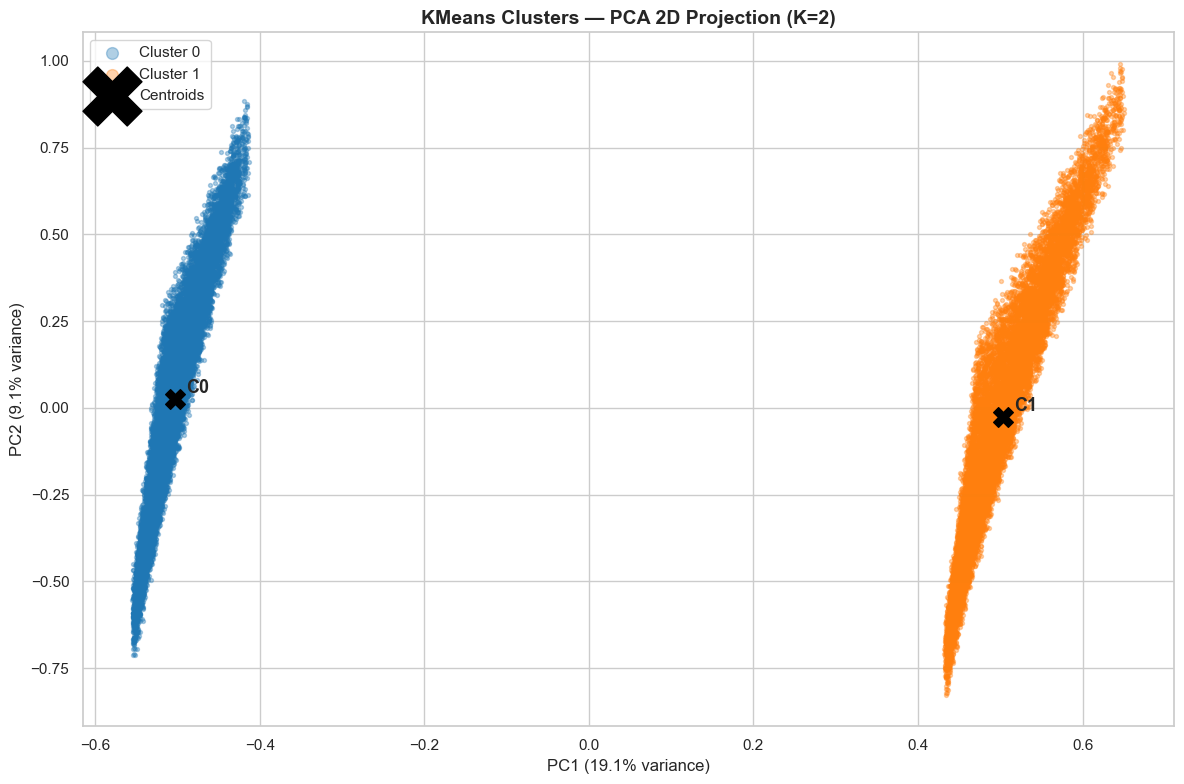

In [11]:
# ── 2D PCA scatter ────────────────────────────────────────────────────────────
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X)

# Sample for plotting speed
PLOT_SAMPLE = min(30_000, len(X))
idx = np.random.RandomState(RANDOM_STATE).choice(len(X), PLOT_SAMPLE, replace=False)
X_2d_s = X_2d[idx]
labels_s = cluster_labels[idx]

fig, ax = plt.subplots(figsize=(12, 8))

for c in range(K):
    mask = labels_s == c
    ax.scatter(X_2d_s[mask, 0], X_2d_s[mask, 1],
               c=[COLORS[c]], alpha=0.35, s=8, label=f'Cluster {c}')

# Plot cluster centroids projected to 2D
centroids_2d = pca_2d.transform(kmeans.cluster_centers_)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           c='black', marker='X', s=200, zorder=5, label='Centroids')
for i, (cx, cy) in enumerate(centroids_2d):
    ax.annotate(f'C{i}', (cx, cy), fontsize=13, fontweight='bold',
                textcoords='offset points', xytext=(8, 4))

ax.set_title(f'KMeans Clusters — PCA 2D Projection (K={K})',
             fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
ax.legend(markerscale=3, fontsize=11)
plt.tight_layout()
plt.show()

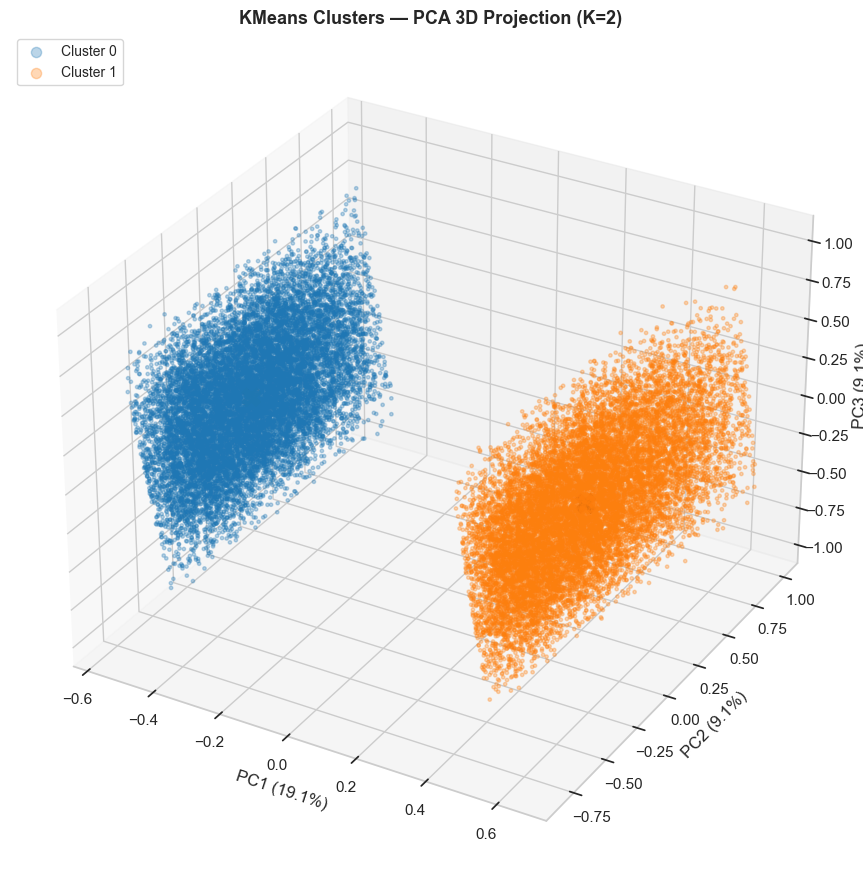

PC1+PC2+PC3 explain: 37.4% of total variance


In [12]:
# ── 3D PCA scatter ────────────────────────────────────────────────────────────
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_3d = pca_3d.fit_transform(X)
X_3d_s = X_3d[idx]

fig = plt.figure(figsize=(13, 9))
ax3 = fig.add_subplot(111, projection='3d')

for c in range(K):
    mask = labels_s == c
    ax3.scatter(X_3d_s[mask, 0], X_3d_s[mask, 1], X_3d_s[mask, 2],
                c=[COLORS[c]], alpha=0.3, s=6, label=f'Cluster {c}')

centroids_3d = pca_3d.transform(kmeans.cluster_centers_)
ax3.scatter(centroids_3d[:, 0], centroids_3d[:, 1], centroids_3d[:, 2],
            c='black', marker='X', s=200, zorder=5)

var3 = pca_3d.explained_variance_ratio_
ax3.set_xlabel(f'PC1 ({var3[0]*100:.1f}%)')
ax3.set_ylabel(f'PC2 ({var3[1]*100:.1f}%)')
ax3.set_zlabel(f'PC3 ({var3[2]*100:.1f}%)')
ax3.set_title(f'KMeans Clusters — PCA 3D Projection (K={K})',
              fontsize=13, fontweight='bold')
ax3.legend(markerscale=3, fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()

print(f'PC1+PC2+PC3 explain: {sum(var3)*100:.1f}% of total variance')

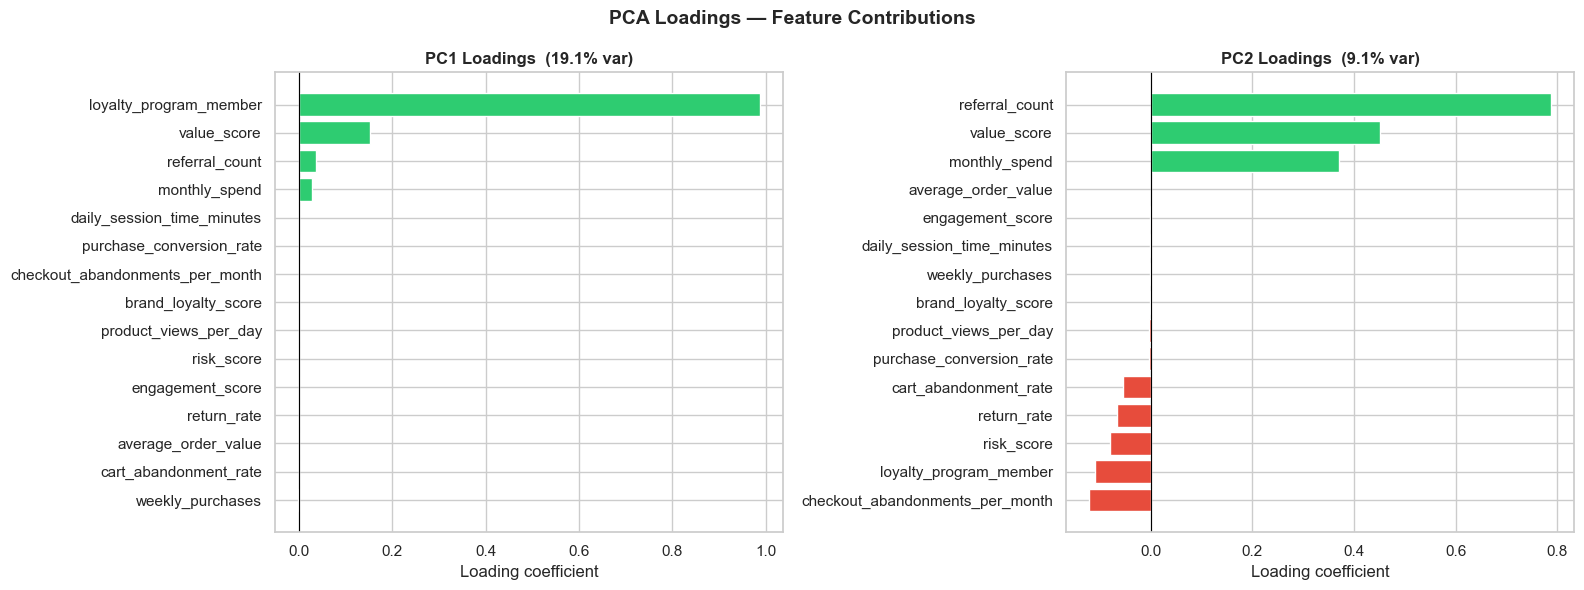

In [13]:
# ── PCA loadings — what drives PC1 & PC2? ────────────────────────────────────
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=CLUSTER_FEATURES,
    columns=['PC1', 'PC2']
).sort_values('PC1', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA Loadings — Feature Contributions', fontsize=14, fontweight='bold')

for ax, pc in zip(axes, ['PC1', 'PC2']):
    data = loadings[pc].sort_values(ascending=True)
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in data]
    ax.barh(data.index, data.values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{pc} Loadings  ({pca_2d.explained_variance_ratio_[int(pc[-1])-1]*100:.1f}% var)',
                 fontweight='bold')
    ax.set_xlabel('Loading coefficient')

plt.tight_layout()
plt.show()

## 6. Cluster Profiling & Persona Naming

We profile each cluster on **raw (unscaled) values** for interpretability, then assign a persona name based on the behavioral signature.

In [14]:
# ── Profile on raw values ─────────────────────────────────────────────────────
PROFILE_COLS = [
    'monthly_spend', 'average_order_value', 'weekly_purchases',
    'loyalty_program_member', 'brand_loyalty_score', 'referral_count',
    'purchase_conversion_rate', 'return_rate',
    'cart_abandonment_rate', 'checkout_abandonments_per_month',
    'daily_session_time_minutes', 'product_views_per_day',
    'impulse_buying_score', 'coupon_usage_frequency',
    'engagement_score', 'value_score', 'risk_score',
    'premium_subscription', 'income_level', 'age',
]
PROFILE_COLS = [c for c in PROFILE_COLS if c in df_raw.columns]

cluster_profile = df_raw.groupby('cluster')[PROFILE_COLS].mean().round(3)

print('=== CLUSTER MEAN PROFILES (raw values) ===')
display(cluster_profile.T.style
        .background_gradient(cmap='RdYlGn', axis=1)
        .format('{:.3f}'))

=== CLUSTER MEAN PROFILES (raw values) ===


cluster,0,1
monthly_spend,2498.160,2499.392
average_order_value,255.079,254.984
weekly_purchases,10.002,9.984
loyalty_program_member,0.000,1.000
brand_loyalty_score,4.997,5.001
referral_count,5.007,5.002
purchase_conversion_rate,49.968,50.035
return_rate,50.013,49.997
cart_abandonment_rate,40.220,40.205
checkout_abandonments_per_month,4.996,4.999


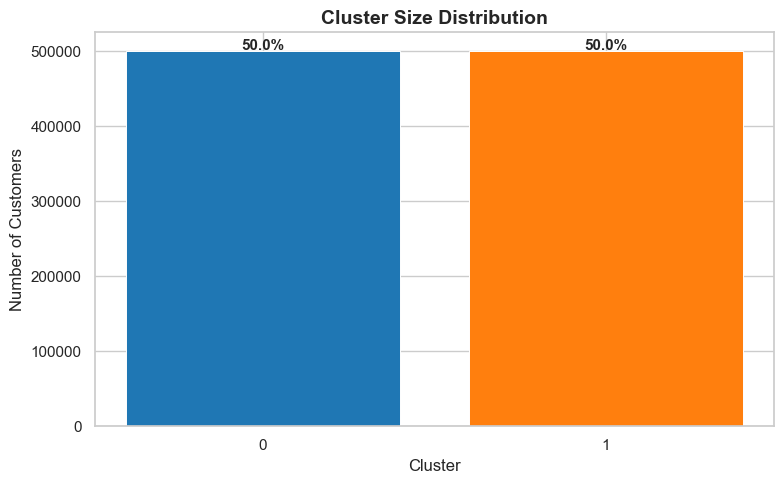

In [15]:
# ── Cluster size summary ──────────────────────────────────────────────────────
size_df = df_raw.groupby('cluster').size().reset_index(name='Count')
size_df['Percentage'] = (size_df['Count'] / len(df_raw) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(size_df['cluster'], size_df['Count'],
              color=[COLORS[i] for i in range(K)], edgecolor='white', linewidth=0.7)
for bar, (_, row) in zip(bars, size_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df_raw)*0.002,
            f'{row["Percentage"]}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Cluster Size Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of Customers')
ax.set_xticks(range(K))
plt.tight_layout()
plt.show()

In [16]:
# ── Persona Naming ────────────────────────────────────────────────────────────
#
# Personas are assigned by ranking clusters on key signals:
#   spend, loyalty, risk_score, engagement_score, conversion_rate
#
# The mapping below is AUTO-GENERATED from the cluster profiles.
# After running the notebook, review the profiles and adjust names as needed.

cp = cluster_profile  # shorthand

def rank_cluster(col, ascending=True):
    """Returns cluster IDs ranked by a column (lowest = rank 0)."""
    return cp[col].rank(ascending=ascending).astype(int).to_dict()

# Composite rank score: higher = more valuable / engaged
rank_spend      = cp['monthly_spend'].rank(ascending=False)
rank_loyalty    = cp['brand_loyalty_score'].rank(ascending=False)
rank_conversion = cp['purchase_conversion_rate'].rank(ascending=False)
rank_risk       = cp['risk_score'].rank(ascending=True)   # low risk = good
rank_engagement = cp['engagement_score'].rank(ascending=False)

value_rank = (rank_spend + rank_loyalty + rank_conversion + rank_risk + rank_engagement)

# Sort clusters by value composite
sorted_clusters = value_rank.sort_values().index.tolist()

# Persona templates — adjust names to match your cluster profiles
PERSONA_TEMPLATES = [
    ('Window Shopper',   '🪟', 'High browse, low buy. Low spend, high cart abandonment.'),
    ('Bargain Hunter',   '🏷️', 'Deal-driven. High coupon use, moderate spend, low loyalty.'),
    ('Casual Buyer',     '🛍️', 'Moderate across all metrics. Occasional, non-loyal shopper.'),
    ('Engaged Regular',  '📱', 'High engagement & conversion. Mid-tier spend, growing loyalty.'),
    ('Loyal Whale',      '🐋', 'Highest spend, loyalty, referrals. Low risk. Premium subscriber.'),
]

# Assign personas in value order (lowest value → Window Shopper, highest → Loyal Whale)
n_templates = len(PERSONA_TEMPLATES)
CLUSTER_PERSONAS = {}
for rank_pos, cluster_id in enumerate(sorted_clusters):
    template_idx = min(rank_pos, n_templates - 1)
    name, emoji, desc = PERSONA_TEMPLATES[template_idx]
    CLUSTER_PERSONAS[cluster_id] = {'name': name, 'emoji': emoji, 'description': desc}

# Add persona labels to dataframes
df_raw['persona'] = df_raw['cluster'].map(lambda c: CLUSTER_PERSONAS[c]['name'])
df_mm['persona']  = df_mm['cluster'].map(lambda c: CLUSTER_PERSONAS[c]['name'])

print('=== PERSONA ASSIGNMENTS ===')
for c, info in sorted(CLUSTER_PERSONAS.items()):
    n = (df_raw['cluster'] == c).sum()
    print(f'  Cluster {c} → {info["emoji"]} {info["name"]:20s} | n={n:,} ({n/len(df_raw)*100:.1f}%)')
    print(f'             {info["description"]}')

=== PERSONA ASSIGNMENTS ===
  Cluster 0 → 🏷️ Bargain Hunter       | n=500,182 (50.0%)
             Deal-driven. High coupon use, moderate spend, low loyalty.
  Cluster 1 → 🪟 Window Shopper       | n=499,818 (50.0%)
             High browse, low buy. Low spend, high cart abandonment.


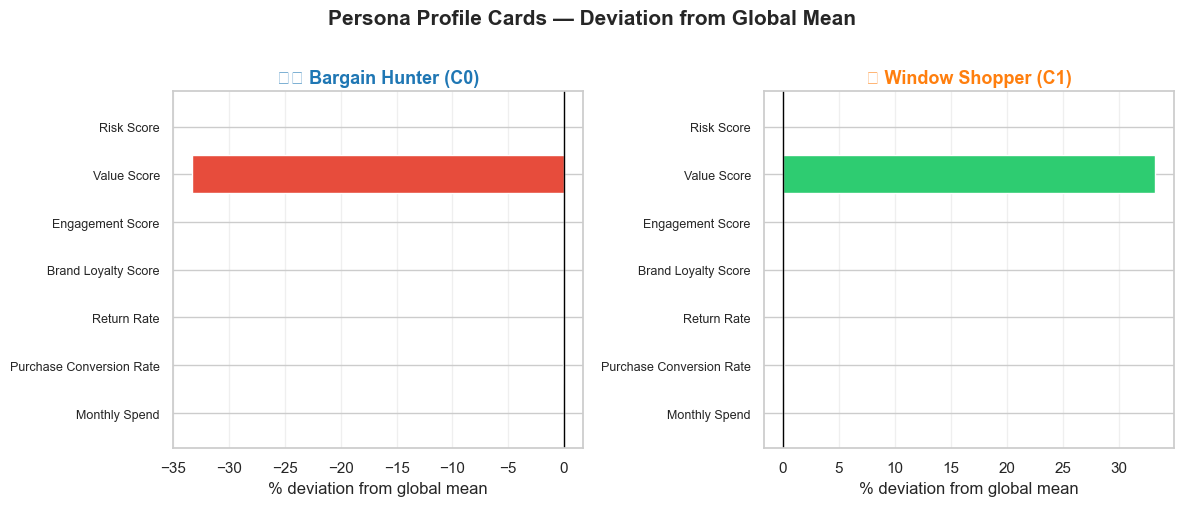

In [17]:
# ── Persona profile cards ─────────────────────────────────────────────────────
KEY_METRICS = ['monthly_spend', 'purchase_conversion_rate', 'return_rate',
               'brand_loyalty_score', 'engagement_score', 'value_score', 'risk_score']
KEY_METRICS = [c for c in KEY_METRICS if c in df_raw.columns]

n_cols = min(K, 3)
n_rows = (K + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
if K == 1:
    axes = [[axes]]
elif n_rows == 1:
    axes = [axes]
axes_flat = [ax for row in axes for ax in (row if hasattr(row, '__iter__') else [row])]

global_means = df_raw[KEY_METRICS].mean()

for c in range(K):
    ax = axes_flat[c]
    persona = CLUSTER_PERSONAS[c]
    cluster_means = cluster_profile.loc[c, KEY_METRICS]

    # Normalize vs global mean for relative bar chart
    relative = ((cluster_means - global_means) / (global_means + 1e-9)) * 100
    bar_colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in relative]

    bars = ax.barh(KEY_METRICS, relative, color=bar_colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'{persona["emoji"]} {persona["name"]} (C{c})',
                 fontsize=13, fontweight='bold', color=COLORS[c])
    ax.set_xlabel('% deviation from global mean')
    ax.set_yticklabels([m.replace('_', ' ').title() for m in KEY_METRICS], fontsize=9)
    ax.grid(True, axis='x', alpha=0.3)

# Hide unused axes
for i in range(K, len(axes_flat)):
    axes_flat[i].set_visible(False)

fig.suptitle('Persona Profile Cards — Deviation from Global Mean',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Heatmap of Cluster Means

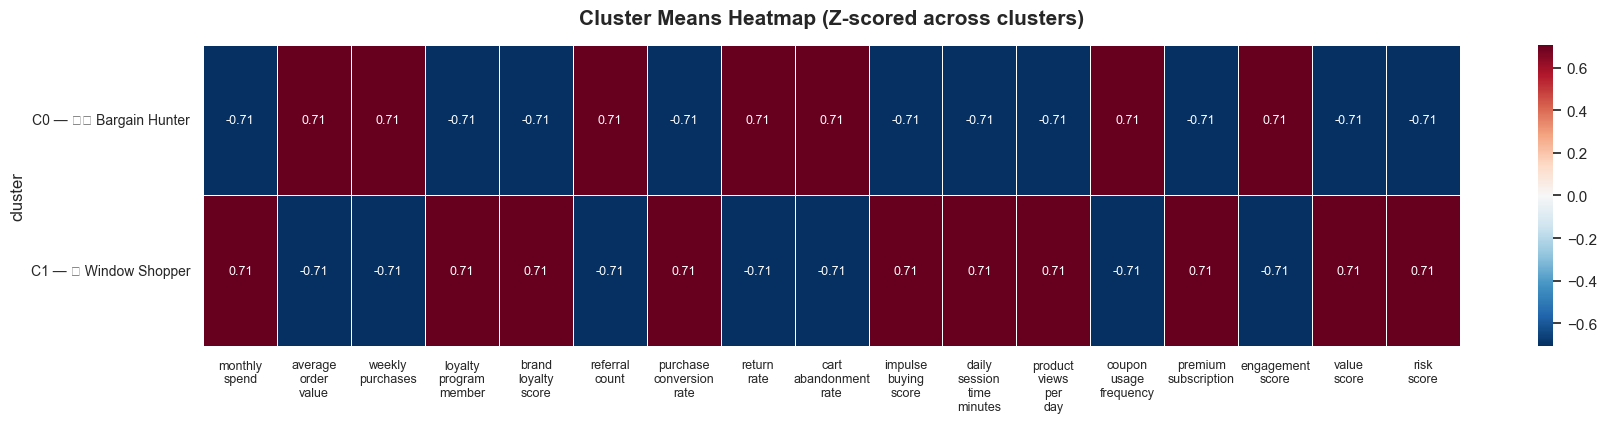

In [18]:
# ── Full cluster mean heatmap (Z-scored for comparability) ────────────────────
heatmap_cols = [
    'monthly_spend', 'average_order_value', 'weekly_purchases',
    'loyalty_program_member', 'brand_loyalty_score', 'referral_count',
    'purchase_conversion_rate', 'return_rate',
    'cart_abandonment_rate', 'impulse_buying_score',
    'daily_session_time_minutes', 'product_views_per_day',
    'coupon_usage_frequency', 'premium_subscription',
    'engagement_score', 'value_score', 'risk_score',
]
heatmap_cols = [c for c in heatmap_cols if c in df_raw.columns]

# Z-score the cluster means so features are on the same scale
hmap_data = df_raw.groupby('cluster')[heatmap_cols].mean()
hmap_z = (hmap_data - hmap_data.mean()) / (hmap_data.std() + 1e-9)

# Row labels with persona names
row_labels = [f'C{c} — {CLUSTER_PERSONAS[c]["emoji"]} {CLUSTER_PERSONAS[c]["name"]}'
              for c in hmap_z.index]

fig, ax = plt.subplots(figsize=(18, max(4, K * 1.2 + 2)))
sns.heatmap(
    hmap_z,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    linewidths=0.5,
    ax=ax,
    yticklabels=row_labels,
    annot_kws={'size': 9}
)
ax.set_title('Cluster Means Heatmap (Z-scored across clusters)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xticklabels([c.replace('_', '\n') for c in heatmap_cols],
                   rotation=0, ha='center', fontsize=9)
ax.set_yticklabels(row_labels, rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

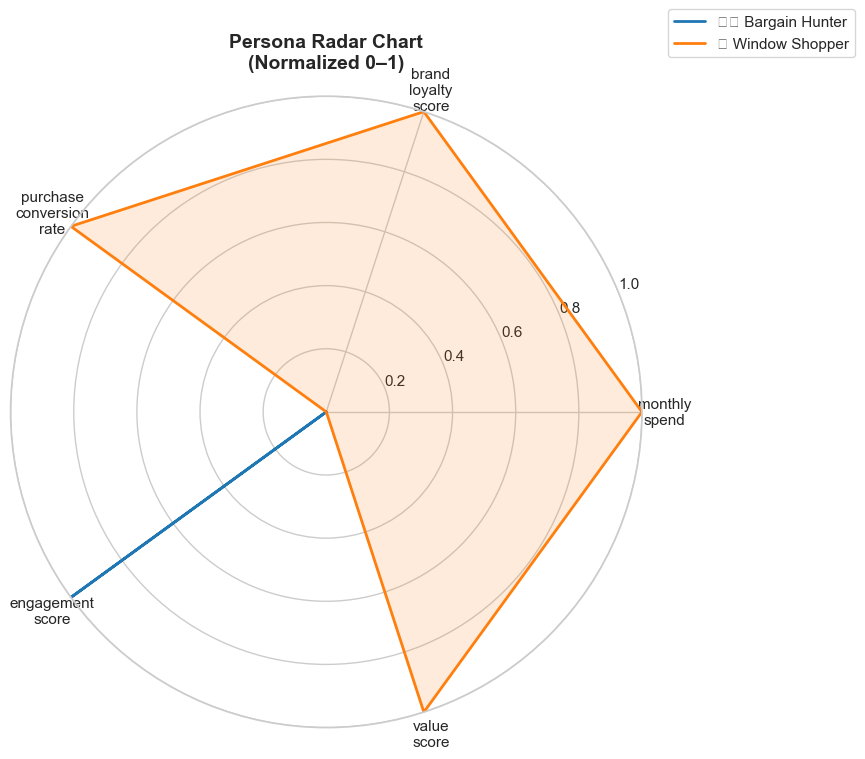

In [19]:
# ── Radar chart of key features per persona ───────────────────────────────────
radar_cols = ['monthly_spend', 'brand_loyalty_score', 'purchase_conversion_rate',
              'engagement_score', 'value_score']
radar_cols = [c for c in radar_cols if c in df_raw.columns]

radar_data = df_raw.groupby('cluster')[radar_cols].mean()
# Normalize to [0,1] across all clusters for radar
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

N = len(radar_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for c in range(K):
    values = radar_norm.loc[c].tolist()
    values += values[:1]
    persona = CLUSTER_PERSONAS[c]
    ax.plot(angles, values, linewidth=2, color=COLORS[c],
            label=f'{persona["emoji"]} {persona["name"]}')
    ax.fill(angles, values, color=COLORS[c], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([c.replace('_', '\n') for c in radar_cols], fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Persona Radar Chart\n(Normalized 0–1)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
plt.tight_layout()
plt.show()

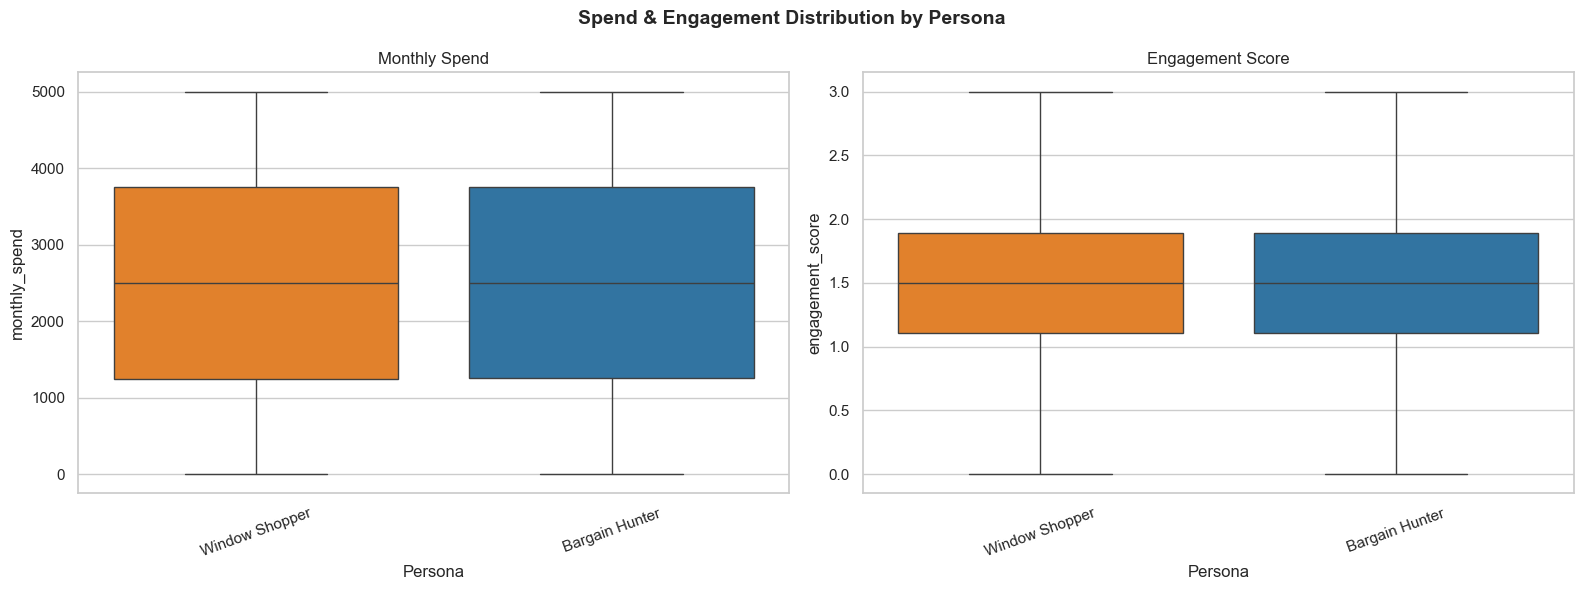

In [20]:
# ── Box plots: monthly_spend & engagement_score by persona ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Spend & Engagement Distribution by Persona', fontsize=14, fontweight='bold')

persona_order = [CLUSTER_PERSONAS[c]['name'] for c in sorted_clusters]
palette = {CLUSTER_PERSONAS[c]['name']: COLORS[c] for c in range(K)}

for ax, col in zip(axes, ['monthly_spend', 'engagement_score']):
    plot_data = df_raw[['persona', col]].copy()
    sns.boxplot(data=plot_data, x='persona', y=col, order=persona_order,
                palette=palette, ax=ax, showfliers=False)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Persona')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

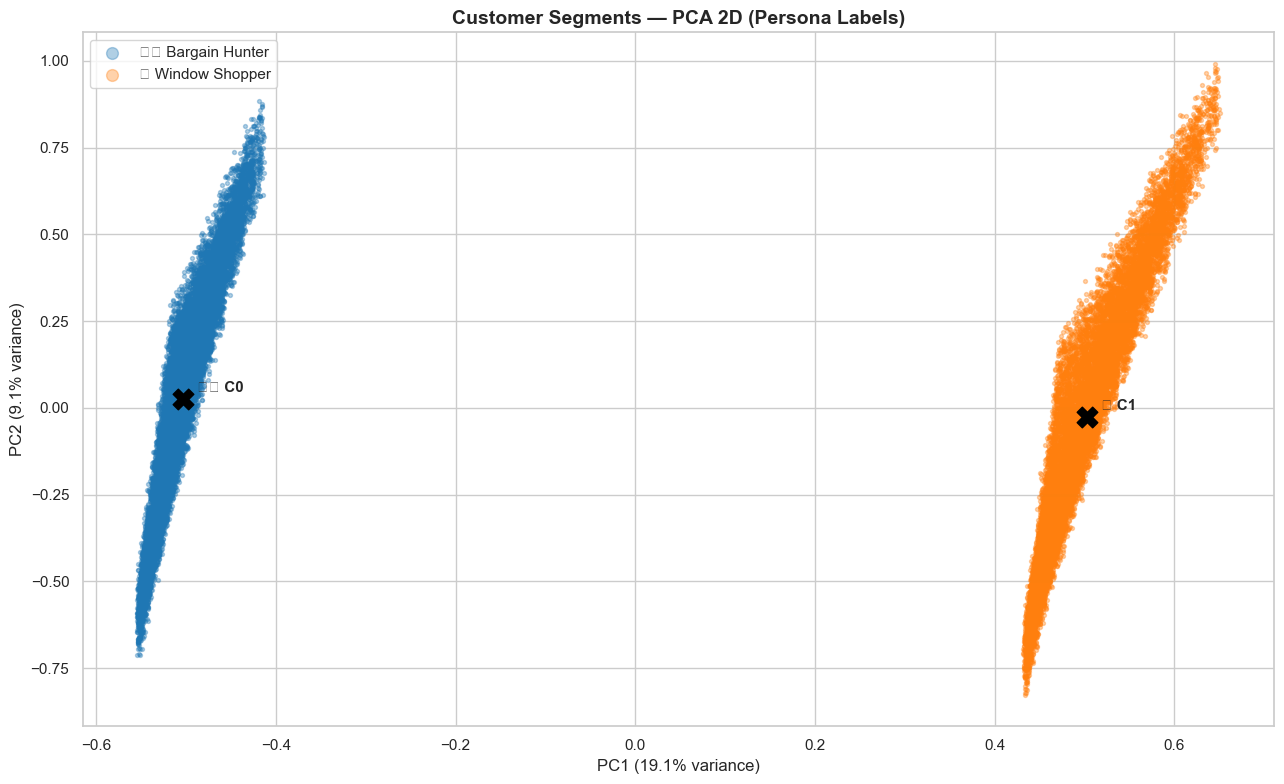

In [21]:
# ── PCA 2D scatter colored by persona name ────────────────────────────────────
persona_labels_s = np.array([CLUSTER_PERSONAS[c]['name'] for c in labels_s])

fig, ax = plt.subplots(figsize=(13, 8))
for c in range(K):
    p = CLUSTER_PERSONAS[c]
    mask = labels_s == c
    ax.scatter(X_2d_s[mask, 0], X_2d_s[mask, 1],
               c=[COLORS[c]], alpha=0.35, s=8,
               label=f'{p["emoji"]} {p["name"]}')

ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           c='black', marker='X', s=220, zorder=5)
for i, (cx, cy) in enumerate(centroids_2d):
    p = CLUSTER_PERSONAS[i]
    ax.annotate(f'{p["emoji"]} C{i}', (cx, cy), fontsize=11, fontweight='bold',
                textcoords='offset points', xytext=(10, 5))

ax.set_title('Customer Segments — PCA 2D (Persona Labels)',
             fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
ax.legend(markerscale=3, fontsize=11, loc='best')
plt.tight_layout()
plt.show()

## 8. Save Segmented Data

In [22]:
OUTPUT_SEG = 'df_segmented.csv'
df_raw.to_csv(OUTPUT_SEG, index=False)

print(f'✅ Segmented dataset saved: {OUTPUT_SEG}  {df_raw.shape}')
print(f'   New columns added: cluster, persona')

# Also save cluster centroids for reference
centroids_df = pd.DataFrame(kmeans.cluster_centers_, columns=CLUSTER_FEATURES)
centroids_df.index.name = 'cluster'
centroids_df['persona'] = [CLUSTER_PERSONAS[c]['name'] for c in range(K)]
centroids_df.to_csv('cluster_centroids.csv')
print('✅ Cluster centroids saved: cluster_centroids.csv')

✅ Segmented dataset saved: df_segmented.csv  (1000000, 853)
   New columns added: cluster, persona
✅ Cluster centroids saved: cluster_centroids.csv


In [23]:
print('=' * 65)
print('         🎯 SEGMENTATION SUMMARY')
print('=' * 65)

print(f'\n🔢 CLUSTERING')
print(f'  • Algorithm          : KMeans (k-means++ init, n_init=20)')
print(f'  • Features used      : {len(CLUSTER_FEATURES)}')
print(f'  • Optimal K          : {K}')
print(f'  • Final inertia      : {kmeans.inertia_:,.2f}')
print(f'  • Silhouette score   : {overall_sil:.4f}')

print(f'\n📐 PCA')
print(f'  • PC1+PC2 variance   : {(explained[0]+explained[1])*100:.1f}%')
print(f'  • PC1+PC2+PC3 var    : {sum(var3)*100:.1f}%')
print(f'  • 80% var @ n_comp   : {n_80}')
print(f'  • 90% var @ n_comp   : {n_90}')

print(f'\n👤 PERSONAS')
for c, info in sorted(CLUSTER_PERSONAS.items()):
    n = (df_raw['cluster'] == c).sum()
    print(f'  • C{c} {info["emoji"]} {info["name"]:20s}: {n:>8,} ({n/len(df_raw)*100:.1f}%)')

print(f'\n📦 OUTPUT FILES')
print(f'  • df_segmented.csv       — raw data + cluster + persona')
print(f'  • cluster_centroids.csv  — KMeans centroid coordinates')

print('\n' + '=' * 65)
print('✅ Segmentation Complete — Proceed to Phase 4: ML Models')
print('=' * 65)

         🎯 SEGMENTATION SUMMARY

🔢 CLUSTERING
  • Algorithm          : KMeans (k-means++ init, n_init=20)
  • Features used      : 15
  • Optimal K          : 2
  • Final inertia      : 1,077,713.59
  • Silhouette score   : 0.1835

📐 PCA
  • PC1+PC2 variance   : 28.3%
  • PC1+PC2+PC3 var    : 37.4%
  • 80% var @ n_comp   : 10
  • 90% var @ n_comp   : 11

👤 PERSONAS
  • C0 🏷️ Bargain Hunter      :  500,182 (50.0%)
  • C1 🪟 Window Shopper      :  499,818 (50.0%)

📦 OUTPUT FILES
  • df_segmented.csv       — raw data + cluster + persona
  • cluster_centroids.csv  — KMeans centroid coordinates

✅ Segmentation Complete — Proceed to Phase 4: ML Models


---
## ✅ Next Steps

| Phase | Notebook | Input | Description |
|-------|----------|-------|-------------|
| Phase 4 | `04_ML_Models.ipynb` | `df_segmented.csv` | Random Forest, XGBoost, Logistic Regression, SHAP |